In [45]:
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as colors
import numpy as np

from sandbox.jordan8 import generate_matrix

from sandbox.plt_dict import matplotlib_update

matplotlib_update()

In [46]:
np.random.seed(4567)
S = np.random.randn(19,19)
E = np.random.randn(19,19)
S2 = np.random.randn(19,19)
# E = E / np.linalg.norm(E)
E = 2e-3 * E
J1 = np.diag([0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1], k=1) + E
J2 = np.diag([0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1], k=1) + E
J3 = np.diag([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0], k=1) + E
J4 = np.diag([0]*18, k=1) + E
S_inv = np.linalg.inv(S)
S_inv2 = np.linalg.inv(S2)

In [47]:
print(np.linalg.norm(E))

0.03744126486262418


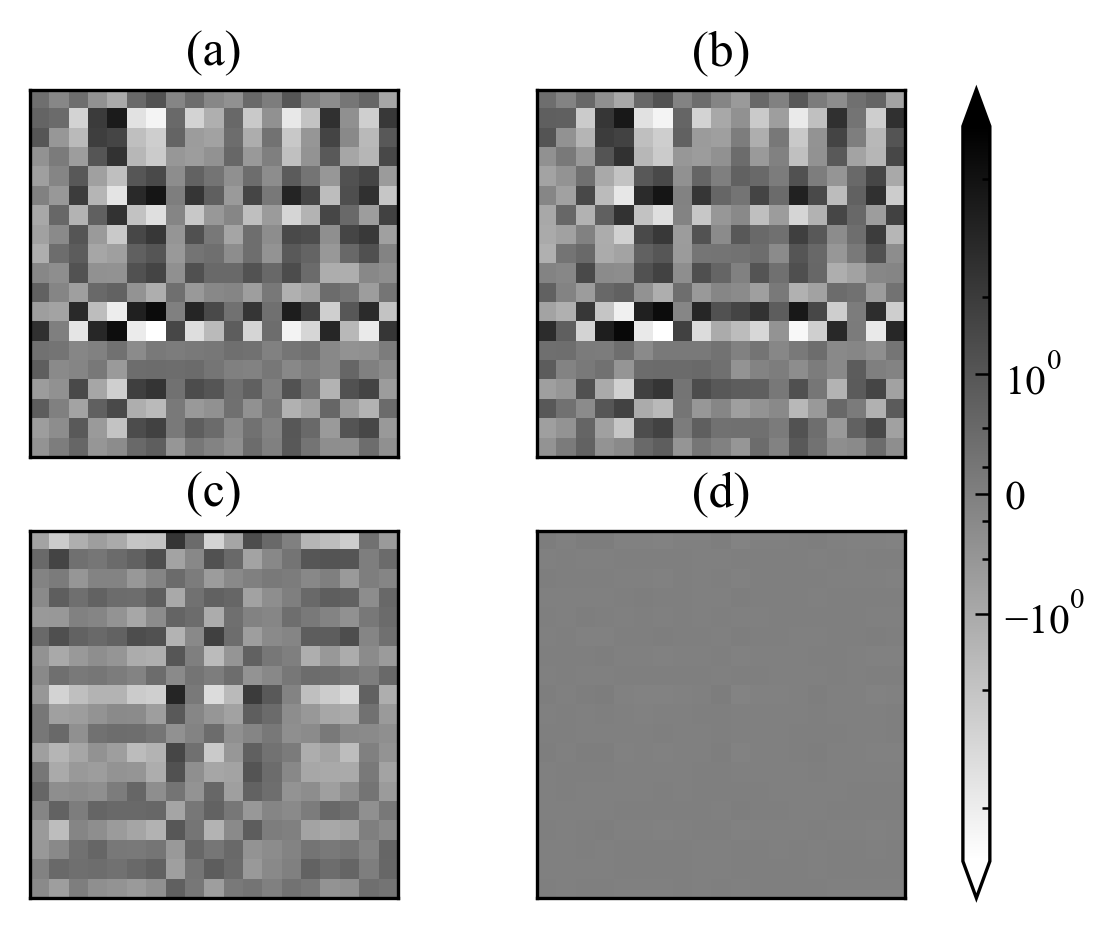

In [48]:
matrices = [S_inv@J1@S, S_inv@J2@S, S_inv2@J3@S2, S_inv2@J4@S2]

global_min = min(np.min(m) for m in matrices)
global_max = max(np.max(m) for m in matrices)
global_min = -max(abs(global_min), abs(global_max))
global_max = max(abs(global_min), abs(global_max))


norm = colors.AsinhNorm(linear_width=1.0, vmin=global_min, vmax=global_max)

fig, axes = plt.subplots(2, 2)
axes = axes.flatten()
letters = ['a', 'b', 'c', 'd']

for i, (ax, mat) in enumerate(zip(axes, matrices)):
    im = ax.matshow(mat, cmap='binary', norm=norm)
    ax.set_title(f"({letters[i]})")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')

# Add the colorbar using the last image object 'im'
# We also manually set ticks if the automatic ones bunch up at the edges
cbar = fig.colorbar(im, ax=axes, orientation='vertical', extend='both', aspect=30, ticks=[10, 1, 0, -1, -10])

plt.savefig("latex/images/random_matrices.pdf")
plt.show()

In [49]:
from sandbox.jordan8 import JordanNet, per_power_features
import torch 


model = JordanNet(encode_dim=32).cpu()
trained_dimensions = [4, 6, 9, 12, 15, 28] +  [35, 33, 25, 23, 19, 13, 7]
for d in trained_dimensions:
    model.add_dimension(d)

model.load_state_dict(torch.load(f"sandbox/model_jordan8_modified.pth", map_location="cpu"))
model.eval()

features = []
for m in matrices:
    features.append(per_power_features(m))

features = torch.tensor(np.stack(features), dtype=torch.float32, device="cpu")
logits = model(19, features)
preds = torch.argmax(logits, dim=-1)


C:\Users\micha\AppData\Local\Temp\ipykernel_18600\571716539.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8_mod

In [50]:
# true class indexes: 3, 7, 3, 0
print(preds)

tensor([3, 7, 3, 0])
